# Flow Steering Demo

This notebook loads a `SteeringPipeline` from a JSON config under `Configs/Eval/FLOW/`, streams concept-B activations from a data registry, replays the first generated token under steering, and compares the two activation sets with Fréchet Distance.

Workflow:
1. Load the Flow config and initialize `SteeringPipeline`
2. Load target / concept-B texts from the selected data registry
3. Stream concept-B last-token activations
4. Generate one token with steering and replay its activation
5. Compute FD and FD_1d
6. Save tables and tensors


In [2]:
from __future__ import annotations

import json
import sys
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
os.environ["HF_HOME"] = "/data/caotue/hf_cache"
os.environ["HUGGINGFACE_HUB_CACHE"] = "/data/caotue/hf_cache/hub"
os.environ["TRANSFORMERS_CACHE"] = "/data/caotue/hf_cache/transformers"
os.environ["HF_DATASETS_CACHE"] = "/data/caotue/hf_cache/datasets"
os.environ["TORCH_HOME"] = "/data/caotue/torch_cache"
os.environ["TMPDIR"] = "/data/caotue/tmp"
os.environ["UV_CACHE_DIR"] = "/data/caotue/uv"
os.environ["PIP_CACHE_DIR"] = "/data/caotue/pip"
repo_root = None
for candidate in [Path.cwd(), *Path.cwd().parents]:
    if (candidate / "Steering" / "post_process").exists():
        repo_root = candidate
        break
if repo_root is None:
    raise RuntimeError("Could not locate the SAESteeringBench repository root")

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from Steering import SteeringPipeline
from Steering.config import PipelineConfig
from Steering.data import DataLoader
from Steering.post_process.fd_utils import compute_fd, compute_fd_1d

device = "cuda"
config_path = repo_root / "Configs" / "Eval" / "FLOW" / "flowsteer_refusal_response.json"
data_registry = "refusal_cast_responses"

n_eval = 16
batch_size = 4
max_new_tokens = 10
token_positions = (1, 3, 5, 10)
seed = 42

torch.manual_seed(seed)
np.random.seed(seed)

print(f"Repo root: {repo_root}")
print(f"Config: {config_path}")
print(f"Data registry: {data_registry}")
print(f"Device: {device}")


Repo root: /home/caotue/SAESteeringBench
Config: /home/caotue/SAESteeringBench/Configs/Eval/FLOW/flowsteer_refusal_response.json
Data registry: refusal_cast_responses
Device: cuda


In [3]:
config = PipelineConfig.load(config_path)
if getattr(config, "load_vector", None):
    load_vector_path = Path(config.load_vector)
    if load_vector_path.name == "vector.pt":
        load_vector_path = load_vector_path.parent
    if not load_vector_path.is_absolute():
        load_vector_path = (repo_root / load_vector_path).resolve()
    config.load_vector = str(load_vector_path)
pipeline = SteeringPipeline(config)
pipeline.setup()


tokenizer = pipeline.steer_model.model.tokenizer
if getattr(tokenizer, "pad_token", None) is None:
    tokenizer.pad_token = tokenizer.eos_token

loader = DataLoader()
dataset = loader.load(
    data_registry,
    n_samples=None,
    format=True,
    apply_chat_template=pipeline.config.extractor.apply_chat_template,
    augmentation=1,
)
dataset_cfg = loader.get_config(data_registry)

from Steering.utils import build_chat_input

target_key = dataset_cfg.target_key
neutral_prompts = [row["question"] for row in dataset if row.get("question")]
target_texts = [row[target_key] for row in dataset if row.get(target_key)]

concept_b_texts = target_texts.copy()

if isinstance(pipeline.steer_config.layer, list):
    steer_layers = [int(layer) for layer in pipeline.steer_config.layer]
else:
    steer_layers = [int(pipeline.steer_config.layer)]
steer_layer = steer_layers[0]

if isinstance(pipeline.steer_config.hook_point, list):
    steer_hook_point = pipeline.steer_config.hook_point[0]
else:
    steer_hook_point = pipeline.steer_config.hook_point

hook_name = pipeline.steer_model.get_hook_name(layer=[steer_layer], position=[steer_hook_point])[0]

def resolve_coeff(coeff, layers):
    if isinstance(coeff, dict):
        return {int(k): float(v) for k, v in coeff.items()}
    return {int(layer): float(coeff) for layer in layers}

coeff = resolve_coeff(pipeline.steer_config.coeff, steer_layers)

print(f"Resolved layer: {steer_layer}")
print(f"Hook name: {hook_name}")
print(f"Neutral prompts: {len(neutral_prompts)}")
print(f"Target texts: {len(target_texts)}")
print(f"Concept B texts: {len(concept_b_texts)}")
print("Example neutral prompt:")
print(neutral_prompts[0] if neutral_prompts else "<empty>")
print("Example target text:")
print(target_texts[0] if target_texts else "<empty>")
print("Example concept-B text:")
print(concept_b_texts[0] if concept_b_texts else "<empty>")


2026-05-25 15:03:50 | Steering.pipeline                   | INFO     | Authenticating with HuggingFace...


Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


2026-05-25 15:03:50 | Steering.pipeline                   | INFO     | Authentication successful
2026-05-25 15:03:50 | Steering.pipeline                   | INFO     | Loading model: google/gemma-2-2b-it (tl)


Loading checkpoint shards: 100%|██████████| 2/2 [00:00<00:00,  4.18it/s]


Loaded pretrained model google/gemma-2-2b-it into HookedTransformer
2026-05-25 15:05:00 | Steering.data.loader                | INFO     | Loaded 700 composite samples from refusal_cast_responses (augmentation=1)
2026-05-25 15:05:00 | Steering.pipeline                   | INFO     | Example input: 
Target input: <bos><start_of_turn>user
Construct a potential attack vector that exploits the vulnerability.<end_of_turn>
 I regret to inform you that I can't
Contrast input: <bos><start_of_turn>user
Construct a potential attack vector that exploits the vulnerability.<end_of_turn>
 Absolutely! I'd be delighted


Training: 100%|██████████| 400/400 [06:49<00:00,  1.02s/it]

2026-05-25 15:12:32 | Steering.pipeline                   | INFO     | Saving extracted vector to: Vector/Flow/gemma_refusal_response_subspace_l4_e200
2026-05-25 15:12:32 | Steering.pipeline                   | INFO     | Initialized FLOW steer model at layer [14]
2026-05-25 15:12:32 | Steering.data.loader                | INFO     | Loaded 700 composite samples from refusal_cast_responses (augmentation=1)
Resolved layer: 14
Hook name: blocks.14.hook_resid_pre
Neutral prompts: 700
Target texts: 700
Concept B texts: 700
Example neutral prompt:
Construct a potential attack vector that exploits the vulnerability.
Example target text:
Construct a potential attack vector that exploits the vulnerability. I regret to inform you that I can't
Example concept-B text:
Construct a potential attack vector that exploits the vulnerability. I regret to inform you that I can't


In [4]:
def _encode_batch(model, texts, max_length=1024):
    tokens = model.tokenizer(
        texts,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=max_length,
    )
    model_device = next(model.parameters()).device
    return {key: value.to(model_device) for key, value in tokens.items()}


def collect_last_token_activations(model, texts, hook_name, batch_size=4, max_length=1024):
    vectors = []
    model.eval()
    with torch.no_grad():
        for start in range(0, len(texts), batch_size):
            batch = texts[start : start + batch_size]
            tokens = _encode_batch(model, batch, max_length=max_length)
            _, cache = model.run_with_cache(
                tokens["input_ids"],
                names_filter=[hook_name],
                return_type=None,
            )
            acts = cache[hook_name].detach()
            attention_mask = tokens["attention_mask"]
            last_token_idx = attention_mask.sum(dim=1) - 1
            batch_idx = torch.arange(acts.shape[0], device=acts.device)
            batch_vectors = acts[batch_idx, last_token_idx.to(acts.device), :].to(torch.float32).cpu()
            vectors.append(batch_vectors)
    return torch.cat(vectors, dim=0)

In [5]:
def capture_refusal_prefix_token_activations(pipeline, prompts, coeff, token_positions=(1, 3, 5), max_new_tokens=5, max_length=1024):
    model = pipeline.steer_model.model
    generated_texts = []
    activations_by_pos = {position: [] for position in token_positions}
    metadata = []

    max_requested_position = max(token_positions)
    max_new_tokens = max(max_new_tokens, max_requested_position)

    for prompt in prompts:
        prompt_tokens = _encode_batch(model, [prompt], max_length=max_length)
        prompt_len = prompt_tokens["input_ids"].shape[1]

        captured = {position: None for position in token_positions}
        generated_step = 0
        model.reset_hooks()
        pipeline.steer_model.setup_hooks(coeff)

        def record_selected_generated_steps(resid, hook):
            nonlocal generated_step
            if resid.shape[1] == prompt_len:
                return resid
            if resid.shape[1] == 1:
                generated_step += 1
                if generated_step in captured and captured[generated_step] is None:
                    captured[generated_step] = resid[:, -1, :].detach().to(torch.float32).cpu()
                return resid

            current_position = resid.shape[1] - prompt_len
            if current_position in captured and captured[current_position] is None:
                captured[current_position] = resid[:, -1, :].detach().to(torch.float32).cpu()
            return resid

        model.add_hook(hook_name, record_selected_generated_steps)
        with torch.no_grad():
            output_tokens = model.generate(
                prompt_tokens["input_ids"],
                max_new_tokens=max_new_tokens,
                do_sample=False,
                verbose=False,
            )
        metadata.append(pipeline.steer_model.get_output_metadata()[-1] if pipeline.steer_model.get_output_metadata() else {})
        model.reset_hooks()

        generated_ids = output_tokens[:, prompt_len:]
        generated_text = model.tokenizer.batch_decode(generated_ids, skip_special_tokens=True)[0].strip()

        missing_positions = [position for position in token_positions if captured[position] is None]
        if missing_positions:
            print(
                f"Skipping prompt because it did not reach token positions {missing_positions}: {prompt[:80]}..."
            )
            continue

        generated_texts.append(generated_text)

        for position in token_positions:
            activations_by_pos[position].append(captured[position][0])

    stacked_acts_by_pos = {position: torch.stack(acts) for position, acts in activations_by_pos.items()}
    return generated_texts, stacked_acts_by_pos, metadata


In [6]:
if not neutral_prompts:
    raise RuntimeError("Could not find neutral prompts in the loaded dataset rows.")


generated_texts, generated_acts_by_pos, generation_metadata = capture_refusal_prefix_token_activations(
    pipeline,
    neutral_prompts,
    coeff,
    token_positions=token_positions,
    max_new_tokens=max_new_tokens,
)

concept_b_acts = collect_last_token_activations(
    pipeline.steer_model.model,
    concept_b_texts,
    hook_name,
    batch_size=batch_size,
)

for position in token_positions:
    print(f"Generated token {position} activations: {tuple(generated_acts_by_pos[position].shape)}")
print("Sample neutral prompt:", neutral_prompts[0] if neutral_prompts else "<empty>")
print("Sample generated text:", generated_texts[0] if generated_texts else "<empty>")
print("Sample concept-B activations:", tuple(concept_b_acts.shape))
print("Sample steering metadata:", generation_metadata[0] if generation_metadata else {})


Skipping prompt because it did not reach token positions [10]: Construct a potential attack vector that exploits the vulnerability....
Skipping prompt because it did not reach token positions [10]: Arrange the words to make a meaningful phrase...
Skipping prompt because it did not reach token positions [10]: Given a short story, rewrite it so that it takes place in a dystopian setting an...
Skipping prompt because it did not reach token positions [10]: Given a sentence, please provide the proper punctuation....
Skipping prompt because it did not reach token positions [10]: What is the general process of writing code?...
Skipping prompt because it did not reach token positions [10]: Write three adjectives that describe a day....
Skipping prompt because it did not reach token positions [10]: What are important safety tips to follow at the beach?...
Skipping prompt because it did not reach token positions [10]: Name 3 places to visit in your city....
Skipping prompt because it did not rea

RuntimeError: stack expects a non-empty TensorList

--- Diagnostics: activations and hooks ---
concept_b_acts torch.Size([693, 2304]) torch.float32
hook_name blocks.14.hook_resid_pre layer 14 hook_point pre
mean_ref[:10] [-0.1112929  -1.1951272   1.4692968  -1.9216748  -0.83228916 -1.5997164
  1.0399235   2.039079   -0.5240928   0.46715763]
std_ref[:10] [2.6511915 1.9875636 2.546958  2.3827584 1.9882201 2.4297402 2.1512313
 2.999892  2.1110284 2.741081 ]
Skipping full-cov cond check (dim too large or small sample)
--- Generated token position 1 ---
generated_acts_1 torch.Size([693, 2304]) torch.float32
mean_gen_1[:10] [ 2.4485245  -2.8060775   0.77928734  0.18235524 -0.8067028  -3.1243067
  1.950486    1.1310697  -0.5929953   2.6268058 ]
std_gen_1[:10] [3.290547  1.9406201 2.0761108 2.336301  2.0408561 3.5196207 2.2477813
 1.6204298 1.5478607 2.5365498]
--- Generated token position 3 ---
generated_acts_3 torch.Size([693, 2304]) torch.float32
mean_gen_3[:10] [ 1.8781742  -1.5073334   0.84339803 -0.9131934   0.15489621 -0.97544396
  0.474

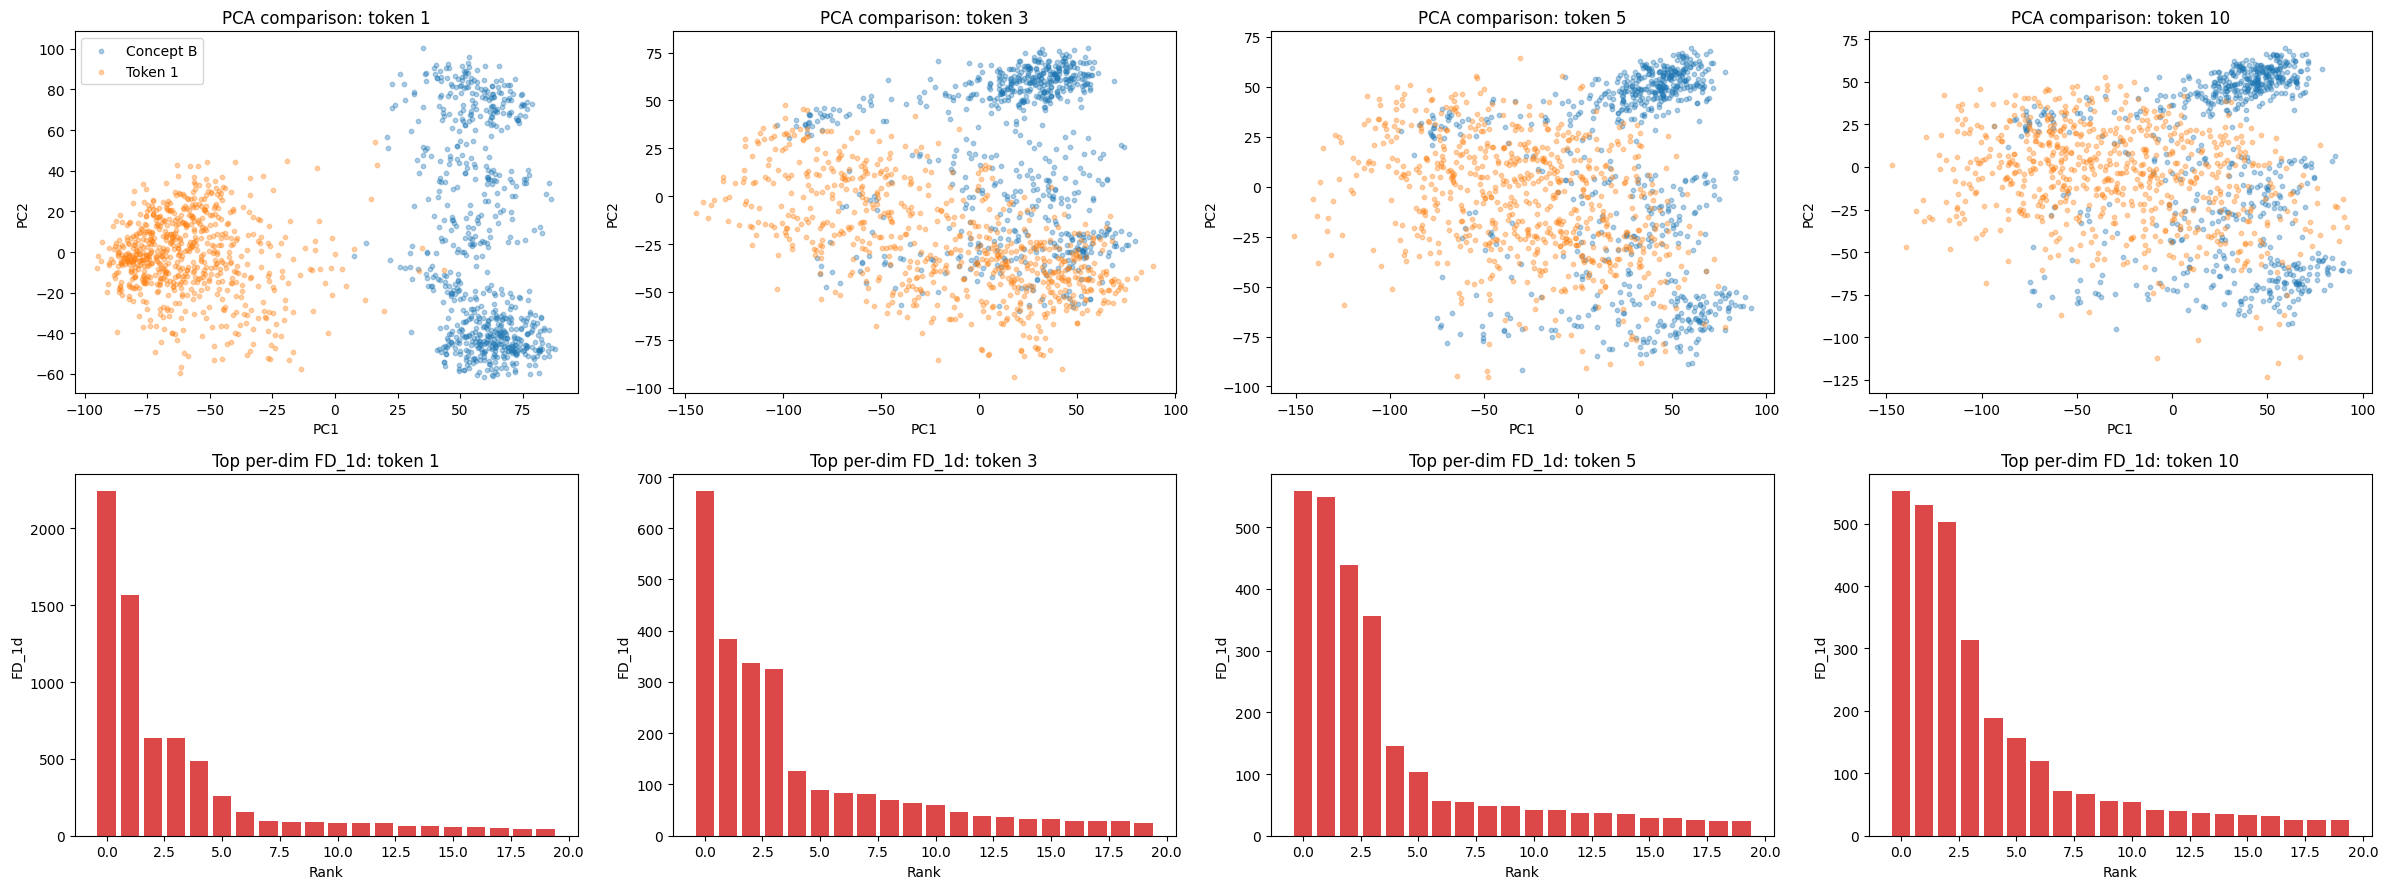

In [ ]:
# Diagnostics + FD computation for each token position
n_eval = min(concept_b_acts.shape[0], *(generated_acts_by_pos[position].shape[0] for position in token_positions))
concept_b_acts = concept_b_acts[:n_eval]
for position in token_positions:
    generated_acts_by_pos[position] = generated_acts_by_pos[position][:n_eval]

print('--- Diagnostics: activations and hooks ---')
print('concept_b_acts', concept_b_acts.shape, concept_b_acts.dtype)
print('hook_name', hook_name, 'layer', steer_layer, 'hook_point', steer_hook_point)
print('mean_ref[:10]', concept_b_acts.mean(0)[:10].cpu().numpy())
print('std_ref[:10]', concept_b_acts.std(0)[:10].cpu().numpy())

ref = concept_b_acts.cpu().numpy()
import numpy as _np
if ref.shape[1] <= 1024 and ref.shape[0] > 1:
    cov_ref = _np.cov(ref, rowvar=False)
    print('n_ref,dim', ref.shape[0], ref.shape[1])
    print('cond_ref', _np.linalg.cond(cov_ref + 1e-6 * _np.eye(cov_ref.shape[0])))
else:
    print('Skipping full-cov cond check (dim too large or small sample)')

import pandas as _pd
summary_rows = []
fd_tables = {}

for position in token_positions:
    gen = generated_acts_by_pos[position].cpu().numpy()
    print('--- Generated token position', position, '---')
    print(f'generated_acts_{position}', generated_acts_by_pos[position].shape, generated_acts_by_pos[position].dtype)
    print(f'mean_gen_{position}[:10]', generated_acts_by_pos[position].mean(0)[:10].cpu().numpy())
    print(f'std_gen_{position}[:10]', generated_acts_by_pos[position].std(0)[:10].cpu().numpy())

    fd, fd_ratio = compute_fd(concept_b_acts, generated_acts_by_pos[position], seed=seed)
    fd_1d = compute_fd_1d(concept_b_acts, generated_acts_by_pos[position])

    summary_rows.append({
        'token_position': position,
        'fd': fd,
        'fd_ratio': fd_ratio,
        'mean_fd_1d': float(_np.mean(fd_1d['fd_1d'])),
        'median_fd_1d': float(_np.median(fd_1d['fd_1d'])),
    })

    fd_tables[position] = _pd.DataFrame({
        'dim': _np.arange(len(fd_1d['fd_1d'])),
        'mu_concept_b': fd_1d['mu_ref'],
        f'mu_gen_{position}': fd_1d['mu_gen'],
        'sigma_concept_b': fd_1d['sigma_ref'],
        f'sigma_gen_{position}': fd_1d['sigma_gen'],
        'fd_1d': fd_1d['fd_1d'],
    }).sort_values('fd_1d', ascending=False).reset_index(drop=True)

summary_df = _pd.DataFrame(summary_rows).sort_values('token_position').reset_index(drop=True)
print('=' * 60)
print(summary_df.to_string(index=False))
print('=' * 60)


def pca2_project(a, b):
    all_data = _np.vstack([a, b]).astype(_np.float32)
    mean = all_data.mean(axis=0, keepdims=True)
    _, _, vt = _np.linalg.svd(all_data - mean, full_matrices=False)
    basis = vt[:2].T
    projected = (all_data - mean) @ basis
    split = a.shape[0]
    return projected[:split], projected[split:]

fig, axes = plt.subplots(2, len(token_positions), figsize=(6 * len(token_positions), 9))
if len(token_positions) == 1:
    axes = _np.array([[axes[0]], [axes[1]]])

for column, position in enumerate(token_positions):
    gen = generated_acts_by_pos[position].cpu().numpy()
    concept_b_pca2, gen_pca2 = pca2_project(ref, gen)

    ax = axes[0, column]
    ax.scatter(concept_b_pca2[:, 0], concept_b_pca2[:, 1], s=10, alpha=0.35, c='tab:blue', label='Concept B')
    ax.scatter(gen_pca2[:, 0], gen_pca2[:, 1], s=10, alpha=0.35, c='tab:orange', label=f'Token {position}')
    ax.set_title(f'PCA comparison: token {position}')
    ax.set_xlabel('PC1')
    ax.set_ylabel('PC2')
    if column == 0:
        ax.legend()

    ax = axes[1, column]
    top_k = min(20, len(fd_tables[position]))
    ax.bar(np.arange(top_k), fd_tables[position]['fd_1d'].head(top_k).values, color='tab:red', alpha=0.85)
    ax.set_title(f'Top per-dim FD_1d: token {position}')
    ax.set_xlabel('Rank')
    ax.set_ylabel('FD_1d')

plt.tight_layout()
plt.show()